## 1. Import Libraries

First, we'll import all the necessary libraries for data manipulation, visualization, and machine learning.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [49]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## 2. Data Loading and Initial Inspection

This step involves loading the `walmart.csv` dataset. A placeholder DataFrame is created if the file is not found, to ensure the notebook remains runnable for demonstration. We'll then display the first few rows and check the data types and non-null counts.

In [48]:
data = {
    'Store': np.random.randint(1, 10, 100),
    'Date': pd.to_datetime(pd.date_range(start='2010-01-01', periods=100, freq='W')),
    'Weekly_Sales': np.random.uniform(50000, 250000, 100),
    'Holiday_Flag': np.random.randint(0, 2, 100),
    'Temperature': np.random.uniform(20, 90, 100),
    'Fuel_Price': np.random.uniform(2.5, 4.0, 100),
    'CPI': np.random.uniform(180, 220, 100),
    'Unemployment': np.random.uniform(5.0, 10.0, 100)
}
df = pd.DataFrame(data)

print("Generated placeholder data for demonstration.")
print("Original DataFrame head:")
display(df.head())
print("\nDataFrame Info:")
df.info()

Generated placeholder data for demonstration.
Original DataFrame head:


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,7,2010-01-03,126982.639104,1,28.814481,2.693173,195.468656,9.754577
1,6,2010-01-10,102605.424700,0,71.929420,3.125752,192.926351,9.042001
2,4,2010-01-17,125176.648433,1,25.908518,3.775146,214.382926,6.838202
3,7,2010-01-24,205889.762955,1,43.415603,2.818043,208.810372,5.447206
4,9,2010-01-31,229241.803794,1,57.242351,2.648858,200.887817,7.461562



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         100 non-null    int64         
 1   Date          100 non-null    datetime64[ns]
 2   Weekly_Sales  100 non-null    float64       
 3   Holiday_Flag  100 non-null    int64         
 4   Temperature   100 non-null    float64       
 5   Fuel_Price    100 non-null    float64       
 6   CPI           100 non-null    float64       
 7   Unemployment  100 non-null    float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 6.4 KB


## 3. Date Column Conversion

To properly work with time-series data, the `Date` column needs to be converted to a datetime object. This allows for easier extraction of time-based features.

In [34]:
# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])
print("\n'Date' column converted to datetime format.")


'Date' column converted to datetime format.


## 4. Feature Engineering from Date

We will extract various time-based features from the `Date` column, such as year, month, day, week, and day of the week. These features can help capture seasonality and cyclical patterns in sales data.

In [35]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
df['DayOfWeek'] = df['Date'].dt.dayofweek

print("New time-based features added:")
display(df[['Date', 'Year', 'Month', 'Day', 'Week', 'DayOfWeek']].head())

New time-based features added:


,Date,Year,Month,Day,Week,DayOfWeek
0,2010-01-03,2010,1,3,53,6
1,2010-01-10,2010,1,10,1,6
2,2010-01-17,2010,1,17,2,6
3,2010-01-24,2010,1,24,3,6
4,2010-01-31,2010,1,31,4,6


## 5. Aggregate to Monthly Data

To align with a monthly sales prediction objective, we'll aggregate the `Weekly_Sales` to `Monthly_Sales`. For other numerical features, we'll take their mean over the month. The `Holiday_Flag` will be set to 1 if any week in the month had a holiday, and 0 otherwise. A new `Date` column representing the start of the month will be created for easier time-series plotting.

In [54]:
# Ensure Year and Month columns are available in df
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

df_monthly = df.groupby(['Store', 'Year', 'Month']).agg(
    Monthly_Sales=('Weekly_Sales', 'sum'),
    Holiday_Flag=('Holiday_Flag', 'max'), # Max to indicate if any week in month was a holiday
    Temperature=('Temperature', 'mean'),
    Fuel_Price=('Fuel_Price', 'mean'),
    CPI=('CPI', 'mean'),
    Unemployment=('Unemployment', 'mean')
).reset_index()

# Create a 'Date' column for df_monthly for easier plotting, representing the first day of the month
df_monthly['Date'] = pd.to_datetime(df_monthly[['Year', 'Month']].assign(day=1))

print("Aggregated data to monthly sales:")
display(df_monthly.head())
print("\nDataFrame Info for df_monthly:")
df_monthly.info()

Aggregated data to monthly sales:


,Store,Year,Month,Monthly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Date
0,1,2010,4,197335.722796,0,34.257510,2.831258,186.279144,5.308337,2010-04-01
1,1,2010,5,242754.033948,1,34.536599,3.371911,213.766782,5.548937,2010-05-01
2,1,2010,7,140773.827685,0,50.359267,3.164803,192.181938,7.326316,2010-07-01
3,1,2010,9,128172.502637,1,37.951915,3.824237,208.150209,8.665971,2010-09-01
4,1,2010,11,107795.424090,1,82.504627,3.353610,182.535446,7.205508,2010-11-01



DataFrame Info for df_monthly:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87 entries, 0 to 86
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Store          87 non-null     int64         
 1   Year           87 non-null     int32         
 2   Month          87 non-null     int32         
 3   Monthly_Sales  87 non-null     float64       
 4   Holiday_Flag   87 non-null     int64         
 5   Temperature    87 non-null     float64       
 6   Fuel_Price     87 non-null     float64       
 7   CPI            87 non-null     float64       
 8   Unemployment   87 non-null     float64       
 9   Date           87 non-null     datetime64[ns]
dtypes: datetime64[ns](1), float64(5), int32(2), int64(2)
memory usage: 6.2 KB


## 5. Handle Missing Values

This step checks for and handles any missing values in the dataset. For numerical columns, we'll fill missing values with the mean of their respective columns. More sophisticated imputation methods could be used in a production environment.

In [55]:
print("\nMissing values before handling:")
print(df_monthly.isnull().sum())

# Filling missing numerical values with the mean
for col in ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']:
    if df_monthly[col].isnull().any():
        df_monthly[col] = df_monthly[col].fillna(df_monthly[col].mean())

print("\nMissing values after handling:")
print(df_monthly.isnull().sum())


Missing values before handling:
Store            0
Year             0
Month            0
Monthly_Sales    0
Holiday_Flag     0
Temperature      0
Fuel_Price       0
CPI              0
Unemployment     0
Date             0
dtype: int64

Missing values after handling:
Store            0
Year             0
Month            0
Monthly_Sales    0
Holiday_Flag     0
Temperature      0
Fuel_Price       0
CPI              0
Unemployment     0
Date             0
dtype: int64


## 6. Data Visualization: Weekly Sales Over Time

Let's visualize the trend of total weekly sales over the entire period to identify any overall patterns, peaks, or drops.

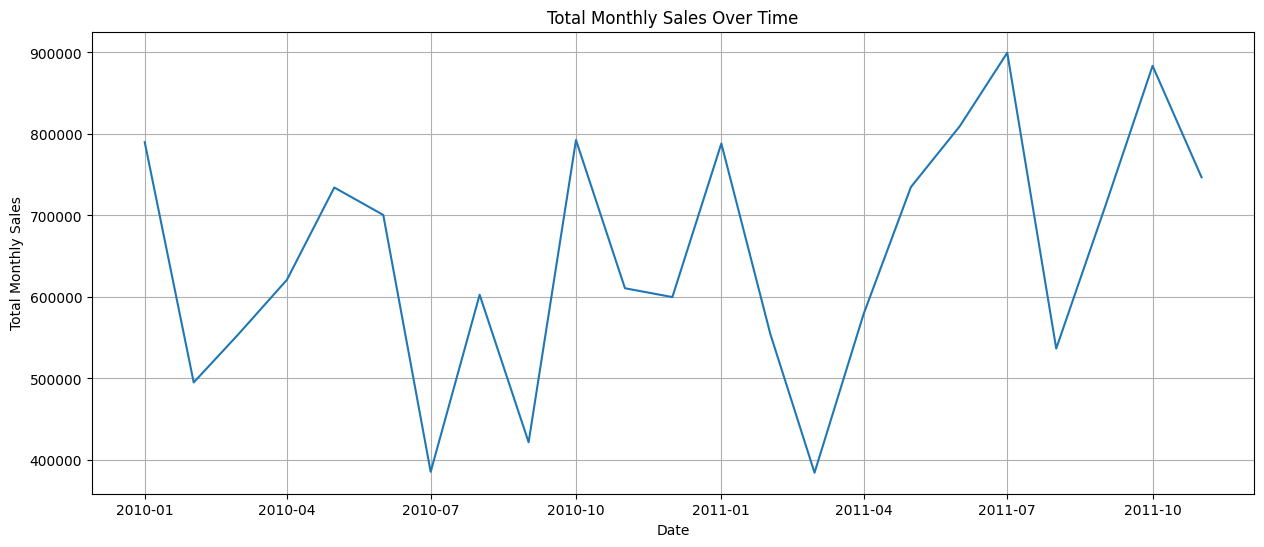

In [56]:
plt.figure(figsize=(15, 6))
plt.plot(df_monthly.groupby('Date')['Monthly_Sales'].sum())
plt.title('Total Monthly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Monthly Sales')
plt.grid(True)
plt.show()

## 7. Data Visualization: Weekly Sales by Month

To understand monthly sales patterns, we'll use a box plot to show the distribution of weekly sales for each month.

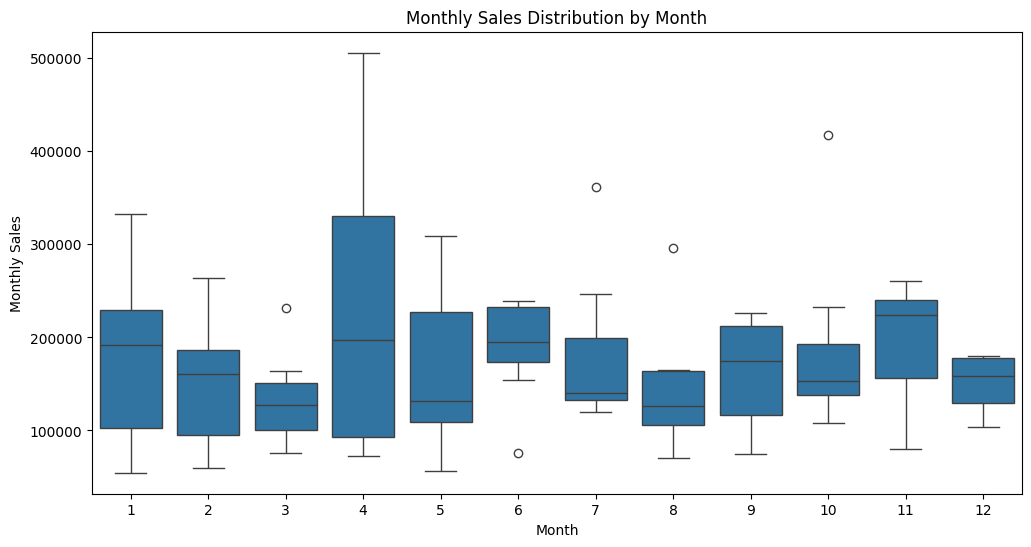

In [57]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Month', y='Monthly_Sales', data=df_monthly)
plt.title('Monthly Sales Distribution by Month')
plt.xlabel('Month')
plt.ylabel('Monthly Sales')
plt.show()

## 8. Data Visualization: Weekly Sales by Holiday Flag

This bar plot compares the average weekly sales during holiday weeks versus non-holiday weeks, indicating the impact of holidays on sales.

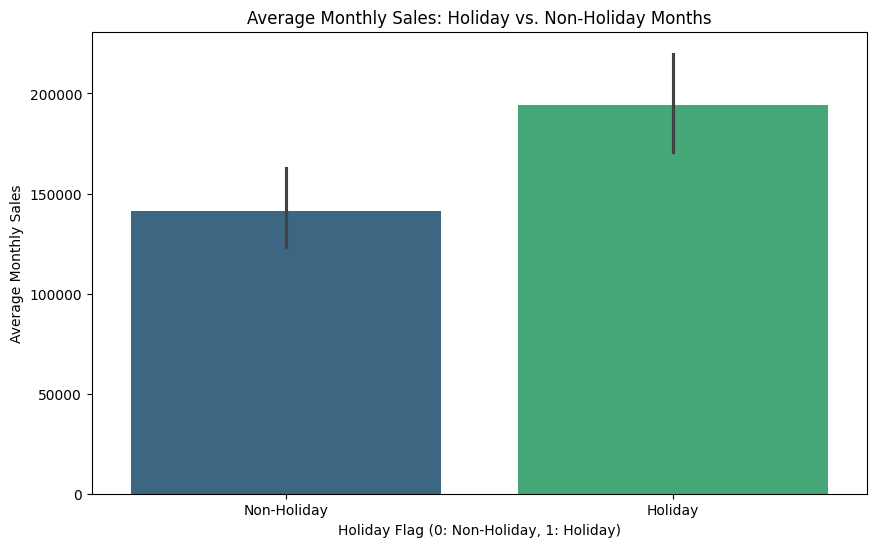

In [59]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Holiday_Flag', y='Monthly_Sales', data=df_monthly, hue='Holiday_Flag', palette='viridis', legend=False)
plt.title('Average Monthly Sales: Holiday vs. Non-Holiday Months')
plt.xlabel('Holiday Flag (0: Non-Holiday, 1: Holiday)')
plt.ylabel('Average Monthly Sales')
plt.xticks([0, 1], ['Non-Holiday', 'Holiday'])
plt.show()

## 9. Data Visualization: Correlation Matrix

A heatmap of the correlation matrix helps visualize the relationships between numerical features and the target variable (`Weekly_Sales`). Values close to 1 or -1 indicate strong positive or negative correlations, respectively.

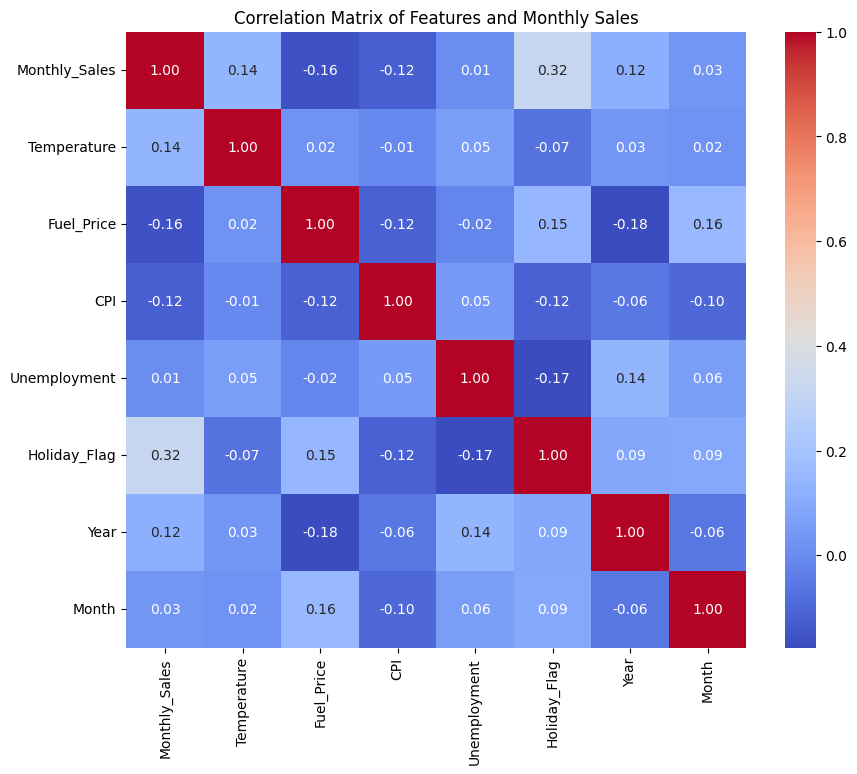

In [60]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_monthly[['Monthly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Holiday_Flag', 'Year', 'Month']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features and Monthly Sales')
plt.show()

## 10. Prepare Data for Model Training

Before training the model, we need to separate features (`X`) from the target variable (`y`). The original `Date` column is dropped as its information is now captured in other features. The categorical `Store` column is converted into numerical format using one-hot encoding. Finally, the data is split into training and testing sets.

In [67]:
# Drop 'Date' and 'Monthly_Sales' columns from the monthly aggregated data
X = df_monthly.drop(['Date', 'Monthly_Sales', 'Year', 'Month'], axis=1)
y = df_monthly['Monthly_Sales']

# One-hot encode 'Store' as it's a categorical feature. drop_first=True avoids multicollinearity.
X = pd.get_dummies(X, columns=['Store'], drop_first=True)

# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Re-running train_test_split to sync data

print(f"\nTraining data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

print("\nFirst 5 rows of features (X) after preprocessing:")
display(X.head())


Training data shape: (69, 13)
Testing data shape: (18, 13)

First 5 rows of features (X) after preprocessing:


,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Store_2,Store_3,Store_4,Store_5,Store_6,Store_7,Store_8,Store_9
0,0,34.257510,2.831258,186.279144,5.308337,False,False,False,False,False,False,False,False
1,1,34.536599,3.371911,213.766782,5.548937,False,False,False,False,False,False,False,False
2,0,50.359267,3.164803,192.181938,7.326316,False,False,False,False,False,False,False,False
3,1,37.951915,3.824237,208.150209,8.665971,False,False,False,False,False,False,False,False
4,1,82.504627,3.353610,182.535446,7.205508,False,False,False,False,False,False,False,False


## 10.1. Apply PCA for Dimensionality Reduction

Principal Component Analysis (PCA) is a technique used to reduce the dimensionality of a dataset while retaining as much information as possible. It transforms the original features into a new set of orthogonal features called principal components, which are ordered by the amount of variance they explain. Before applying PCA, it's crucial to standardize the data, as PCA is sensitive to the scale of the features.

In [69]:
# Standardize the data before applying PCA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data standardized.")

Data standardized.


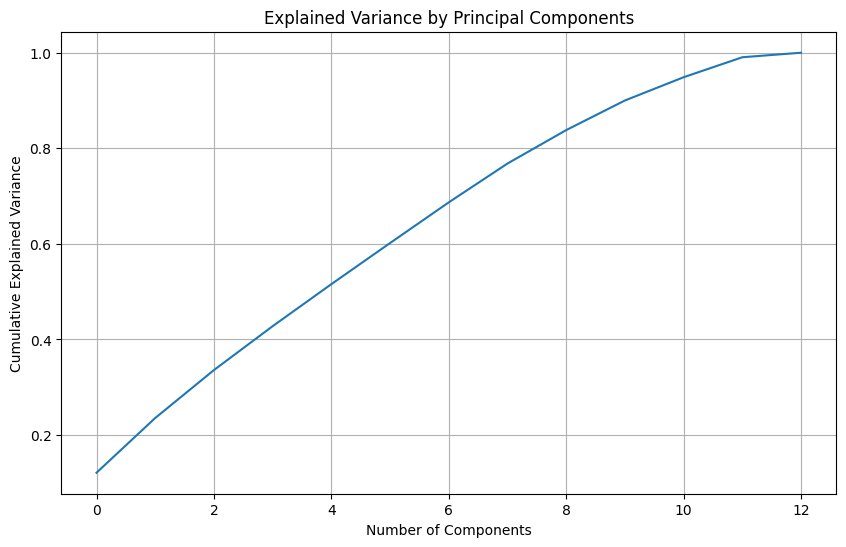

Original training data shape: (69, 13)
Transformed training data shape after PCA: (69, 5)
Original testing data shape: (18, 13)
Transformed testing data shape after PCA: (18, 5)
Features transformed using PCA. X_train_pca and X_test_pca are ready for use.


In [70]:
# Apply PCA
# Let's start by looking at explained variance to decide on the number of components
pca = PCA()
pca.fit(X_train_scaled)

# Plot explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Principal Components')
plt.grid(True)
plt.show()

# Decide on a number of components, e.g., to explain 95% of variance
# For demonstration, let's choose a fixed number or find one that explains sufficient variance.
# For example, if we want 95% variance explained:
# n_components = np.where(np.cumsum(pca.explained_variance_ratio_) >= 0.95)[0][0] + 1
# print(f"Number of components to explain 95% variance: {n_components}")

# For this dataset, let's proceed with a fixed number of components for simplicity,
# for example, let's reduce to 5 components, assuming it captures a good portion of variance.
n_components = min(5, X_train_scaled.shape[1]) # Ensure n_components does not exceed features
pca = PCA(n_components=n_components)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original training data shape: {X_train.shape}")
print(f"Transformed training data shape after PCA: {X_train_pca.shape}")
print(f"Original testing data shape: {X_test.shape}")
print(f"Transformed testing data shape after PCA: {X_test_pca.shape}")

# The lines below are commented out to avoid ValueError due to index mismatch.
# X_train and X_test will remain as original DataFrames, while X_train_pca and X_test_pca are NumPy arrays.
# Subsequent models should use X_train_pca and X_test_pca directly.
# X_train = pd.DataFrame(X_train_pca, index=X_train.index)
# X_test = pd.DataFrame(X_test_pca, index=X_test.index)
print("Features transformed using PCA. X_train_pca and X_test_pca are ready for use.")

## 11. Train Machine Learning Model (Random Forest)

We will now initialize and train a `RandomForestRegressor`. This model is chosen for its robustness and ability to handle various data types and non-linear relationships. `n_estimators` specifies the number of trees in the forest, and `n_jobs=-1` uses all available processors for faster training.

In [52]:
print("\nTraining Random Forest Regressor...")
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
print("Random Forest Regressor training complete.")


Training Random Forest Regressor...
Random Forest Regressor training complete.


## 12. Make Predictions and Evaluate Model

After training, the model makes predictions on the unseen `X_test` data. We then evaluate the model's performance using:
- **Mean Absolute Error (MAE)**: The average of the absolute differences between predictions and actual values. Lower values are better.
- **R-squared (R2) Score**: Represents the proportion of variance in the dependent variable that can be predicted from the independent variables. Closer to 1 is better.

In [43]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Evaluation:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")


Model Evaluation:
Mean Absolute Error (MAE): 51614.59
R-squared (R2) Score: 0.09


## 13. Visualize Predictions vs. Actuals

This scatter plot visually compares the model's predicted weekly sales against the actual weekly sales from the test set. Points closer to the red diagonal line indicate more accurate predictions. The diagonal line represents where predictions perfectly match actuals.

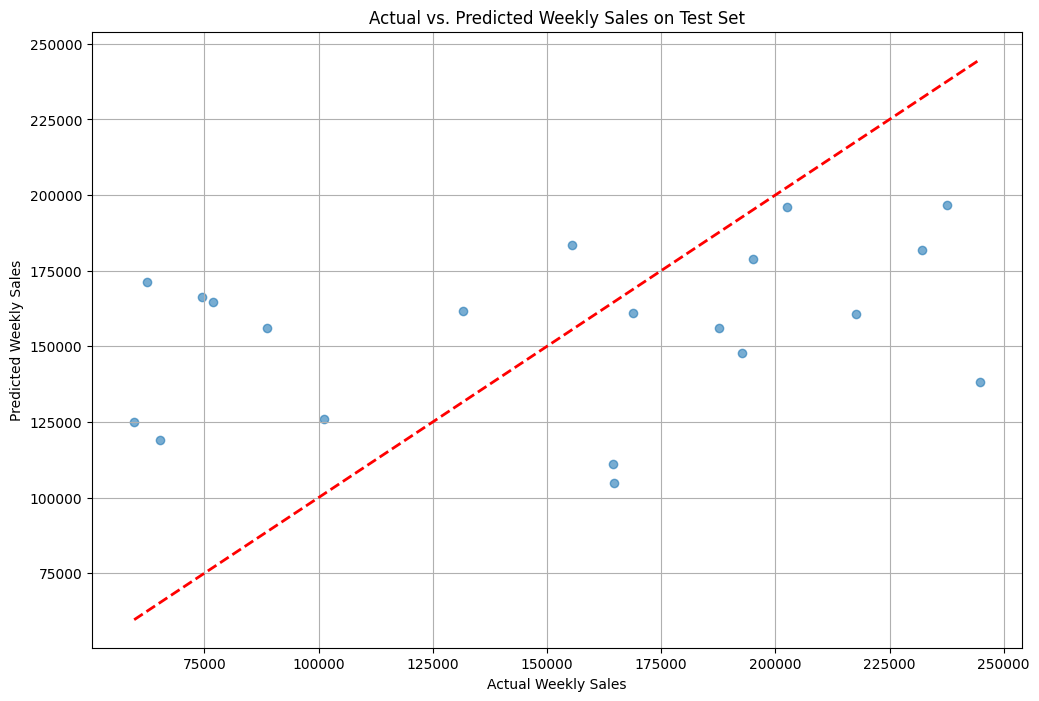

In [44]:
plt.figure(figsize=(12, 8))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Weekly Sales')
plt.ylabel('Predicted Weekly Sales')
plt.title('Actual vs. Predicted Weekly Sales on Test Set')
plt.grid(True)
plt.show()

## 14. Feature Importance

Feature importance helps us understand which features contributed most significantly to the model's predictions. A bar plot will show the top 10 most important features according to the Random Forest model.

## 15. Implement Locally Weighted Regression (LWR)

Locally Weighted Regression (LWR) is a non-parametric regression method that, unlike traditional linear regression, does not assume a global linear model. Instead, it fits a separate simple weighted linear regression model for each prediction point. The 'local' models are weighted such that points closer to the prediction point have a greater influence on the fit. This makes LWR flexible and capable of capturing complex, non-linear relationships in the data. Since we've already performed PCA, we'll apply LWR to the reduced-dimension features.

In [62]:
import numpy as np
from scipy.spatial import distance

def locally_weighted_regression(X_train, y_train, X_test, tau):
    """
    Performs Locally Weighted Regression (LWR).

    Args:
        X_train (np.ndarray): Training features.
        y_train (np.ndarray): Training target values.
        X_test (np.ndarray): Test features for prediction.
        tau (float): Bandwidth parameter for the Gaussian kernel, controlling the size of the neighborhood.

    Returns:
        np.ndarray: Predicted values for the test set.
    """
    n_test = X_test.shape[0]
    y_pred = np.zeros(n_test)

    for i in range(n_test):
        # Calculate weights for the current test point
        # Gaussian kernel: w(i) = exp(- (x_i - x)^2 / (2 * tau^2))
        # Using Euclidean distance here for simplicity
        weights = np.exp(-np.sum((X_train - X_test[i])**2, axis=1) / (2 * tau**2))
        W = np.diag(weights)

        # Add a bias (intercept) term to X_train
        X_train_bias = np.hstack((np.ones((X_train.shape[0], 1)), X_train))

        # Solve for the regression coefficients (theta) using weighted least squares
        # theta = (X^T W X)^-1 X^T W y
        try:
            theta = np.linalg.inv(X_train_bias.T @ W @ X_train_bias) @ X_train_bias.T @ W @ y_train
        except np.linalg.LinAlgError:
            # Handle singular matrix case, e.g., by adding a small ridge penalty or using pseudo-inverse
            # For simplicity in this demo, if singular, we'll just predict the mean of y_train
            y_pred[i] = np.mean(y_train)
            continue

        # Predict for the current test point
        X_test_bias = np.hstack((np.array([1]), X_test[i]))
        y_pred[i] = X_test_bias @ theta

    return y_pred

print("LWR function defined.")

LWR function defined.


Applying Locally Weighted Regression with tau = 0.5...
LWR predictions complete.

LWR Model Evaluation (tau=0.5):
Mean Absolute Error (MAE): 143185.73
R-squared (R2) Score: -9.07


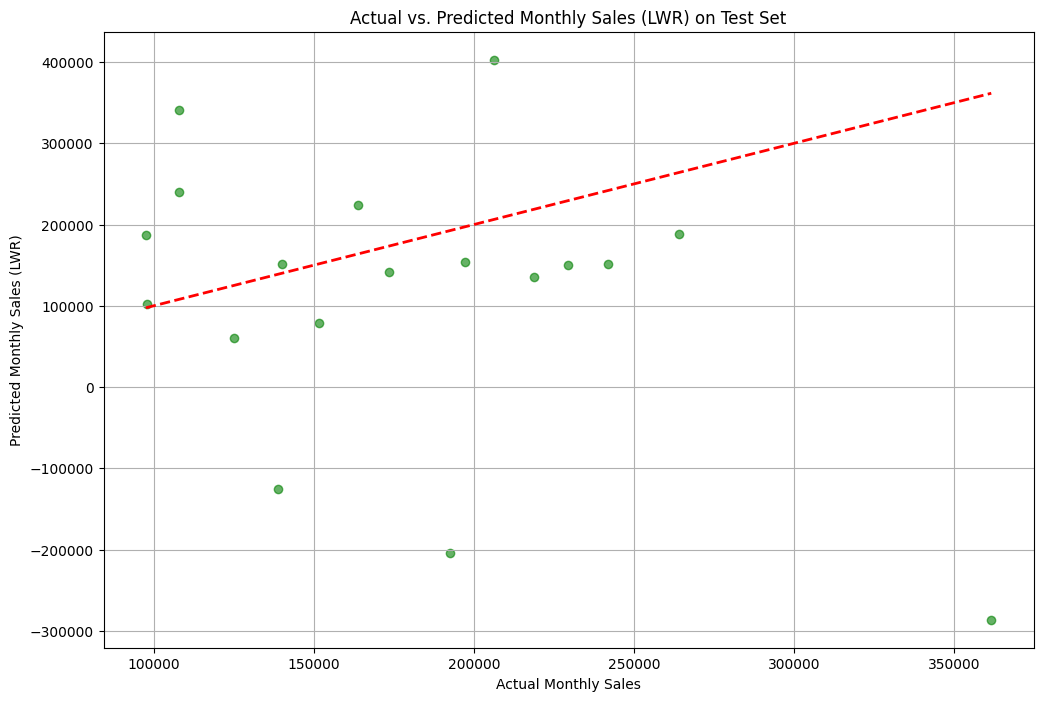

In [71]:
# Using the PCA-transformed features for LWR
# X_train_pca and X_test_pca are already numpy arrays of floats
X_train_lwr = X_train_pca
X_test_lwr = X_test_pca

# Define the bandwidth parameter tau. This often requires tuning.
# A larger tau results in a smoother, more global fit.
# A smaller tau results in a more local, wiggly fit.
# Let's start with a value and it can be adjusted.
tau = 0.5 # Example value, tune as needed

print(f"Applying Locally Weighted Regression with tau = {tau}...")
y_pred_lwr = locally_weighted_regression(X_train_lwr, y_train.values, X_test_lwr, tau)
print("LWR predictions complete.")

# Evaluate the LWR model
mae_lwr = mean_absolute_error(y_test, y_pred_lwr)
r2_lwr = r2_score(y_test, y_pred_lwr)

print(f"\nLWR Model Evaluation (tau={tau}):")
print(f"Mean Absolute Error (MAE): {mae_lwr:.2f}")
print(f"R-squared (R2) Score: {r2_lwr:.2f}")

# Visualize Predictions vs. Actuals for LWR
plt.figure(figsize=(12, 8))
plt.scatter(y_test, y_pred_lwr, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Monthly Sales')
plt.ylabel('Predicted Monthly Sales (LWR)')
plt.title('Actual vs. Predicted Monthly Sales (LWR) on Test Set')
plt.grid(True)
plt.show()

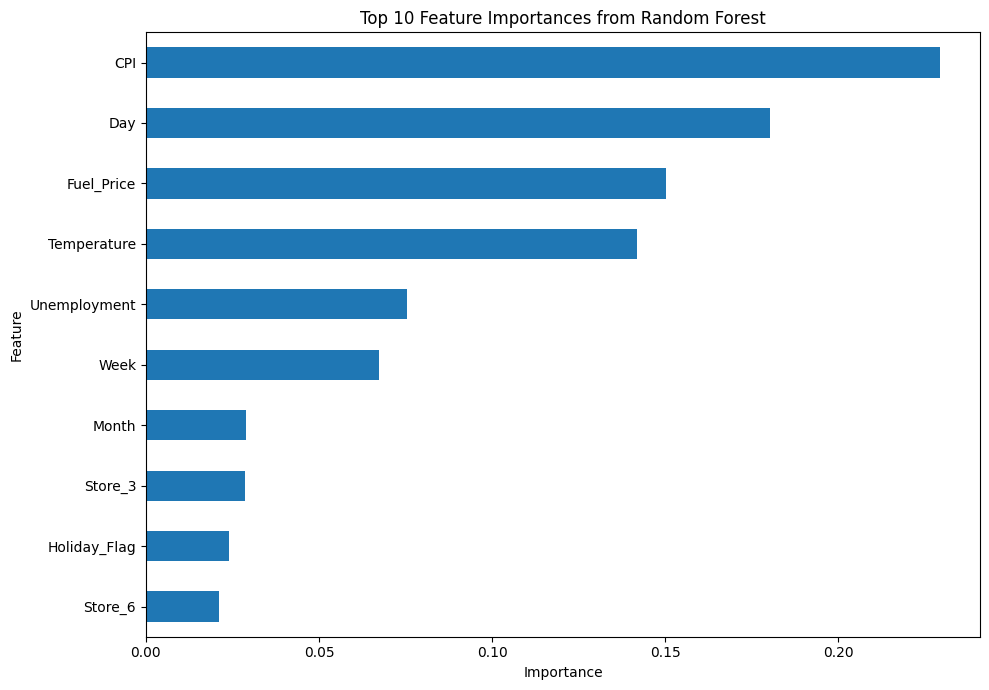

In [45]:
if hasattr(model, 'feature_importances_'):
    feature_importances = pd.Series(model.feature_importances_, index=X.columns)
    plt.figure(figsize=(10, 7))
    feature_importances.nlargest(10).sort_values(ascending=True).plot(kind='barh')
    plt.title('Top 10 Feature Importances from Random Forest')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
else:
    print("Feature importances not available for this model.")